# Five-channel walkthrough: membranes and multichannel profiles

Each field has phase contrast (`C1`), outer membrane (`C2`), inner membrane (`C3`), RNA (`C4`), and DAPI/nucleoid (`C5`). This example emphasizes membrane measurements; the [three-channel example](3_channel_example_walkthrough.ipynb) emphasizes small GFP-DnaN objects. The workflow segments, builds meshes, curates them with its bundled SVM, detects signal objects, and extracts features.

Run from top to bottom. The first code cell points to the example folder; images, masks, and outputs stay there. Change `RUN_DIR` if you moved that folder. The bundled masks allow `RUN_SEGMENTATION = False`. Other programs' masks work if the background is **0** and cells are consecutively labeled **1…N** in a same-size 2D TIFF. Segmentation uses a GPU when available and otherwise runs on CPU. See the [README](../README.md) for installation.

In [75]:
from pathlib import Path
import sys
import torch
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# Import BactoScoop
# Import the package installed in this notebook kernel.
import bactoscoop
import bactoscoop.plot as bplt

%load_ext autoreload
%autoreload 2

# Paths
# Locate the downloaded examples; keep the supplied inputs unchanged.
import os
import shutil
from datetime import datetime

EXAMPLES_DIR = os.environ.get("BACTOSCOOP_EXAMPLES_DIR")
candidates = ([Path(EXAMPLES_DIR)] if EXAMPLES_DIR else
              [candidate for base in (Path.cwd(), *Path.cwd().parents)
               for candidate in (base / "examples", base)])
SOURCE_DIR = next((base / "5_channel_example" for base in candidates
                   if (base / "5_channel_example").is_dir()), None)
if SOURCE_DIR is None:
    raise FileNotFoundError("Open this notebook from the downloaded examples folder, "
                            "or set BACTOSCOOP_EXAMPLES_DIR to that folder.")
RUN_DIR = Path.home() / "bactoscoop_runs" / datetime.now().strftime("%Y%m%d_%H%M%S_%f") / "5_channel_example"
shutil.copytree(SOURCE_DIR, RUN_DIR)
MODEL_PATH = RUN_DIR / "keio_collection_stationary.pkl"

# Settings
RUN_SEGMENTATION = False  # Reuse supplied masks; set True for fresh Omnipose inference.
PIXEL_SIZE_UM = 0.065
PHASE_CHANNEL = "C1"

EXAMPLE_FIELD = "Sample_E4_XY4"
EXAMPLE_CELL_ID = 30

# Channels
OUTER_MEMBRANE = "C2"
INNER_MEMBRANE = "C3"
RNA_CHANNEL = "C4"
DAPI_CHANNEL = "C5"

SIGNAL_CHANNELS = [
    OUTER_MEMBRANE, INNER_MEMBRANE, RNA_CHANNEL, DAPI_CHANNEL
]

CHANNEL_LABELS = {
    "C1": "Phase contrast",
    "C2": "Outer membrane",
    "C3": "Inner membrane",
    "C4": "RNA",
    "C5": "DAPI / nucleoid",
}

# Validate paths
if not RUN_DIR.is_dir():
    raise FileNotFoundError(RUN_DIR)

if not MODEL_PATH.is_file():
    raise FileNotFoundError(MODEL_PATH)

(RUN_DIR / "masks").mkdir(exist_ok=True)

FIELD_IDS = bplt.list_field_ids(RUN_DIR, phase_channel=PHASE_CHANNEL)

print("Fields:", FIELD_IDS)
print("Image directory:", RUN_DIR)
print("CUDA available:", torch.cuda.is_available())
print("Working copy and outputs:", RUN_DIR)
print("CUDA available:", torch.cuda.is_available(), "(segmentation uses CPU when False)")

OUTER_MEMBRANE = "C2"
INNER_MEMBRANE = "C3"
RNA_CHANNEL = "C4"
DAPI_CHANNEL = "C5"
SIGNAL_CHANNELS = [OUTER_MEMBRANE, INNER_MEMBRANE, RNA_CHANNEL, DAPI_CHANNEL]
CHANNEL_LABELS = {"C1": "Phase contrast", "C2": "Outer membrane", "C3": "Inner membrane",
                  "C4": "RNA", "C5": "DAPI / nucleoid"}


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Fields: ['Sample_E4_XY3', 'Sample_E4_XY4']
Image directory: C:\Users\Bart\bactoscoop\examples\5_channel_example
CUDA available: True
Working copy and outputs: C:\Users\Bart\bactoscoop\examples\5_channel_example
CUDA available: True (segmentation uses CPU when False)


## 1. Inspect the input channels

Each field shares a stem and has one TIFF for each channel. Display contrast is adjusted per panel; analysis uses the original values. C2 and C3 mark membranes, while C4 and C5 show intracellular signal.

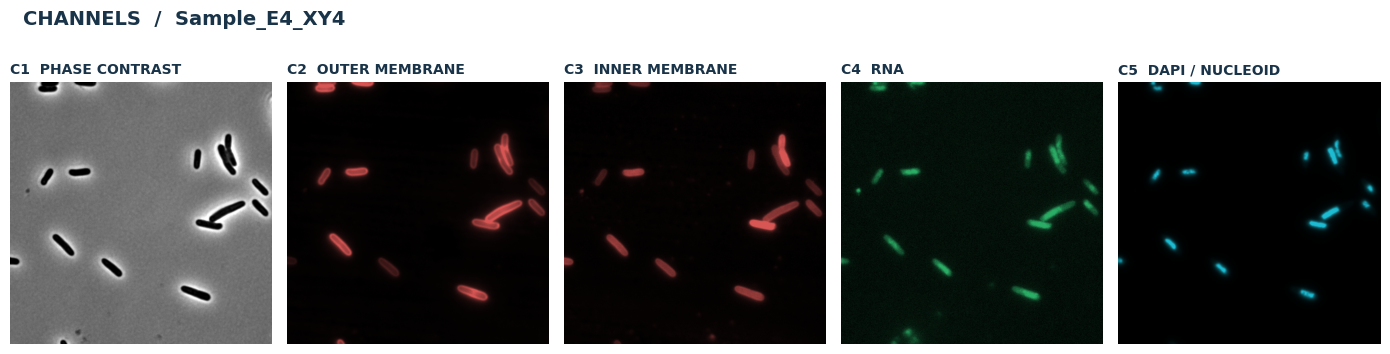

In [76]:
fig = bplt.plot_multichannel_overview(RUN_DIR, FIELD_IDS[1], CHANNEL_LABELS)
display(fig)
plt.close(fig)

## 2. Segment and review

`RUN_SEGMENTATION=True` runs Omnipose on C1. `minsize` filters small segments and `mask_thresh` sets mask confidence. The supplied masks are in the example folder and can be reused by switching the flag off. Set `SEGMENTATION_FIELD`, `SEGMENTATION_LABEL`, `SEGMENTATION_CENTER`, and `SEGMENTATION_CROP_PX` in the review cell, then rerun it to inspect another label or area. The default crop shows several cells; reduce it for a close check. Both panels show the same cell-centered crop; the right panel adds mask outlines and marks the selected label in cyan.

In [77]:
ic = bactoscoop.ImageCollection(str(RUN_DIR), px=PIXEL_SIZE_UM)
ic.load_phase_images(phase_channel=PHASE_CHANNEL)
if RUN_SEGMENTATION:
    ok = ic.segment_images(
        mask_thresh=1, minsize=100, n=range(len(ic.images)),
        model_name="bact_phase_omni",
    )
    if not ok:
        raise RuntimeError(ic.processing_summary())

2026-10-01 16:14:52,957 [INFO] 2 TIFF files found in folder: C:\Users\Bart\bactoscoop\examples\5_channel_example
2026-10-01 16:14:52,961 [INFO] ** TORCH GPU version installed and working. **
>>> GPU activated? True
2026-10-01 16:14:52,963 [INFO] >>bact_phase_omni<< model set to be used
2026-10-01 16:14:52,965 [INFO] ** TORCH GPU version installed and working. **
2026-10-01 16:14:52,965 [INFO] >>>> using GPU
2026-10-01 16:15:11,971 [INFO] 100%|##########| 2/2 [00:18<00:00,  9.32s/it]


2026-10-01 16:15:12,893 [INFO] 2 TIFF files found in folder: C:\Users\Bart\bactoscoop\examples\5_channel_example/masks


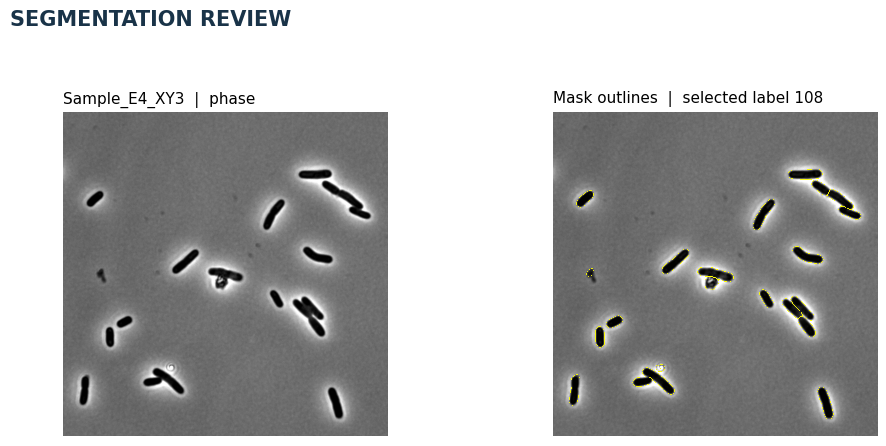

In [78]:

ic.create_image_objects(phase_channel=PHASE_CHANNEL)
SEGMENTATION_FIELD = None
SEGMENTATION_LABEL = None
SEGMENTATION_CENTER = None
SEGMENTATION_CROP_PX = 700
review_field = SEGMENTATION_FIELD or FIELD_IDS[0]
review_image = next(image for image in ic.image_objects
                    if image.image_name.rsplit("_", 1)[0] == review_field)
fig = bplt.plot_segmentation_review(
    [review_image], crop_size=SEGMENTATION_CROP_PX,
    mask_label=SEGMENTATION_LABEL, center=SEGMENTATION_CENTER,
)
display(fig)
plt.close(fig)

## 3.1 Build and inspect meshes

Build contours, paired mesh sides, and midlines from the segmentation masks. At this stage, inspect geometry on the phase image only. `join_thresh` joins nearby poles in pixels; `split_thresh` controls division at constrictions; `smoothing` controls mesh smoothness; `CD_width` selects the width-based constriction measure. `save_data=True` writes `5_channel_example_meshdata.pkl` in `RUN_DIR`.

In [79]:
ic.batch_process_mesh(
    phase_channel=PHASE_CHANNEL, join_thresh=4, split_thresh=0.5,
    CD_width=False, smoothing=0.1, save_data=True,
)
print(f"Meshes: {sum(len(image.cells) for image in ic.image_objects):,}")


2026-10-01 16:15:13,693 [INFO] PROCESSING IMAGE: Sample_E4_XY3_C1.tiff
2026-10-01 16:15:13,694 [INFO] >>> Joining cells ...


100%|██████████| 225/225 [00:07<00:00, 31.56it/s]


2026-10-01 16:15:33,669 [INFO] >>> Creating meshes from joined masks ...


100%|██████████| 209/209 [00:08<00:00, 25.54it/s]


2026-10-01 16:15:42,663 [INFO] >>> Splitting cells ...


...

2026-10-01 16:16:04,074 [INFO] >>> Creating meshes from joined masks ...


100%|██████████| 212/212 [00:08<00:00, 25.62it/s]


2026-10-01 16:16:13,122 [INFO] >>> Splitting cells ...


212it [00:00, 232.39it/s]

Cell objects are created from processed meshes. 217 Cell objects are created.
Meshes: 433


## Optional loading of the meshes "_meshdata.pkl"

In [80]:
# Load the save mesh data from the previous run
ic.batch_load_mesh("5_channel_example_meshdata.pkl", phase_channel=PHASE_CHANNEL)

2026-10-01 16:16:14,364 [INFO] Meshes loaded from file: 5_channel_example_meshdata.pkl


## 3.2 Visualizing the mesh coordinate system

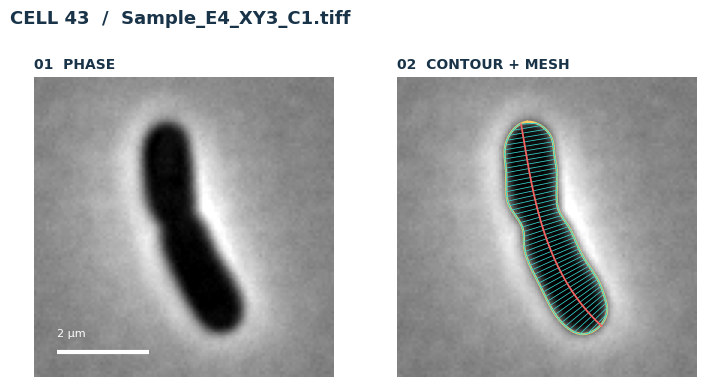

In [81]:
fig = bplt.plot_cell_gallery(image_object=ic.image_objects[0],cell_id=43, channel=None, window_px=100)
display(fig)
plt.close(fig)

## 4. Curate with the supplied SVM

`keio_collection_stationary.pkl` is the example's SVM. It computes morphology features and removes rejected cells; green contours stay and red contours are removed. `save_curated_data=True` writes `5_channel_example_curated_meshdata.pkl` in `RUN_DIR`. Review curation and load only trusted model files.

Fluorescence channels are loaded at the object-detection stage, after curation.

2026-10-01 16:16:15,030 [INFO] PROCESSING CHANNEL: None, method: svm


100%|██████████| 2/2 [00:03<00:00,  1.67s/it]



Number of removed rows: 0
2026-10-01 16:16:18,793 [INFO] 
Proportion of label 1: 0.5302325581395348
Proportion of label 0: 0.4697674418604651
SVM curation: 433 to 228 cells


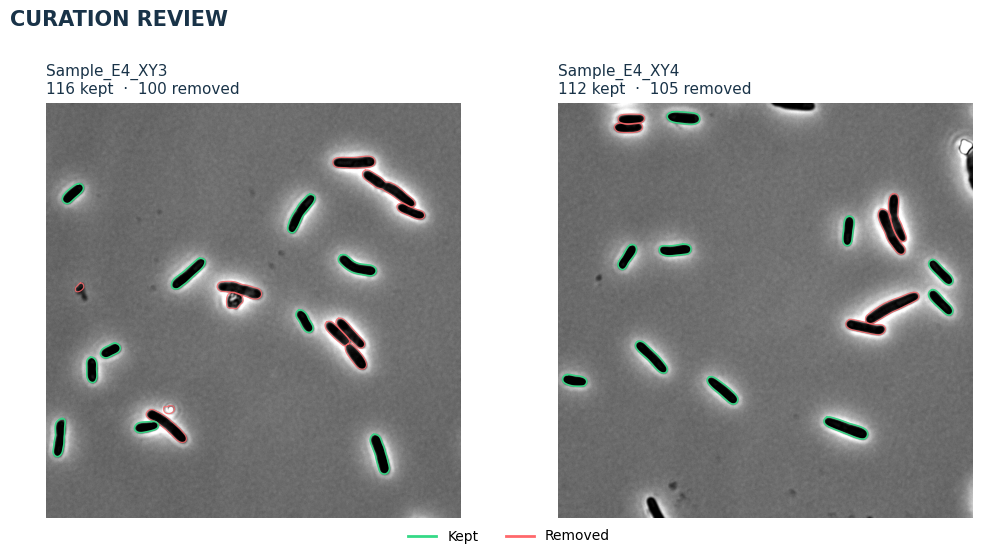

In [82]:
before_contours = bplt.snapshot_cell_contours(ic.image_objects)
before_count = sum(len(image.cells) for image in ic.image_objects)
ic.curate_dataset(str(MODEL_PATH), control=False, save_curated_data=True)
after_count = sum(len(image.cells) for image in ic.image_objects)
print(f"SVM curation: {before_count:,} to {after_count:,} cells")
fig = bplt.plot_curation_review(before_contours, ic.image_objects)
display(fig)
plt.close(fig)

## 5.1 Detect and review objects

Object detection is a central BactoScoop step: it loads the fluorescence channels, finds signal regions for each curated cell, and stores their contours and meshes. As in our high-throughput processing script, C2 uses local phase alignment (`align=True`); C3-C5 use their original coordinates. `reset_channels=False` in the second call keeps the C2 detections. Tune `smoothing`, `log_sigma`, `kernel_width`, and the overlap limits for your data.

The C2 figure is shown **after detection**. Its signal crop uses the same local registration as C2 detection. Gold is the cell contour; cyan shows a detected C2 object. Choose the image and cell ID in the visualization code cells below. Inspect the aligned signal and detected outlines before interpreting object features.

In [83]:
detections_c2 = ic.batch_detect_objects(
    channels=[OUTER_MEMBRANE], reset_channels=True, smoothing=0.1,
    align=True, log_sigma=3, kernel_width=3,
    min_overlap_ratio=0.001, max_external_ratio=0.4,
)
detections_c345 = ic.batch_detect_objects(
    channels=[INNER_MEMBRANE, RNA_CHANNEL, DAPI_CHANNEL],
    reset_channels=False, align=False, smoothing=0.1, log_sigma=3,
    kernel_width=3, min_overlap_ratio=0.001, max_external_ratio=0.3,
)
print("Detected objects by channel:")
display(pd.concat([detections_c2, detections_c345])["channel"].value_counts())

2026-10-01 16:16:19,541 [INFO] 2 TIFF files found in folder: C:\Users\Bart\bactoscoop\examples\5_channel_example
2026-10-01 16:16:19,541 [INFO] Detecting objects within cell ...


100%|██████████| 2/2 [00:04<00:00,  2.24s/it]

2026-10-01 16:16:24,034 [INFO] channel
C2    218
Name: count, dtype: int64
2026-10-01 16:16:24,057 [INFO] 2 TIFF files found in folder: C:\Users\Bart\bactoscoop\examples\5_channel_example
2026-10-01 16:16:24,076 [INFO] 2 TIFF files found in folder: C:\Users\Bart\bactoscoop\examples\5_channel_example
2026-10-01 16:16:24,101 [INFO] 2 TIFF files found in folder: C:\Users\Bart\bactoscoop\examples\5_channel_example
2026-10-01 16:16:24,101 [INFO] Detecting objects within cell ...



100%|██████████| 2/2 [00:08<00:00,  4.22s/it]

2026-10-01 16:16:32,546 [INFO] channel
C4    228
C5    227
C3    219
Name: count, dtype: int64
Detected objects by channel:


channel
C4    228
C5    227
C3    219
C2    218
Name: count, dtype: int64

### 5.2 Looking whether alignment works correctly

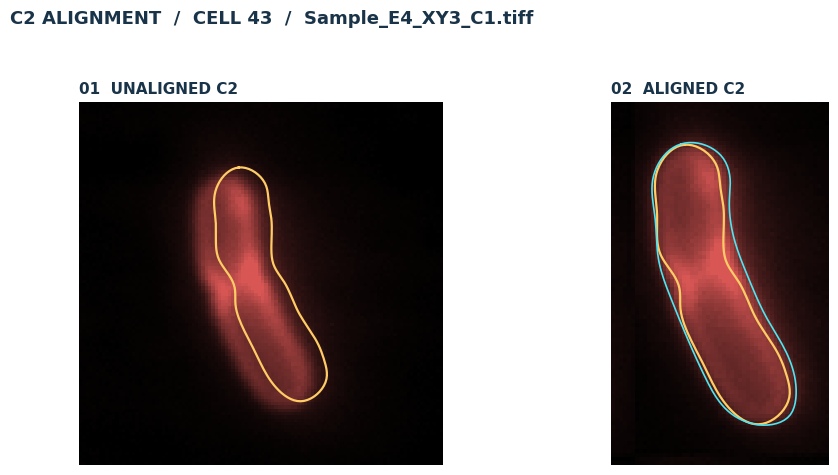

In [84]:
fig = bplt.plot_C2_alignment(
    ic.image_objects[0],
    cell_id=43,
    window_px=110,
    channel="C2",
    channel_label="Outer membrane",
    show_objects=True,
)
display(fig)
plt.close(fig)

## 5.2 Visualize object channels

Aligned C2 example: Sample_E4_XY3_C1.tiff 43


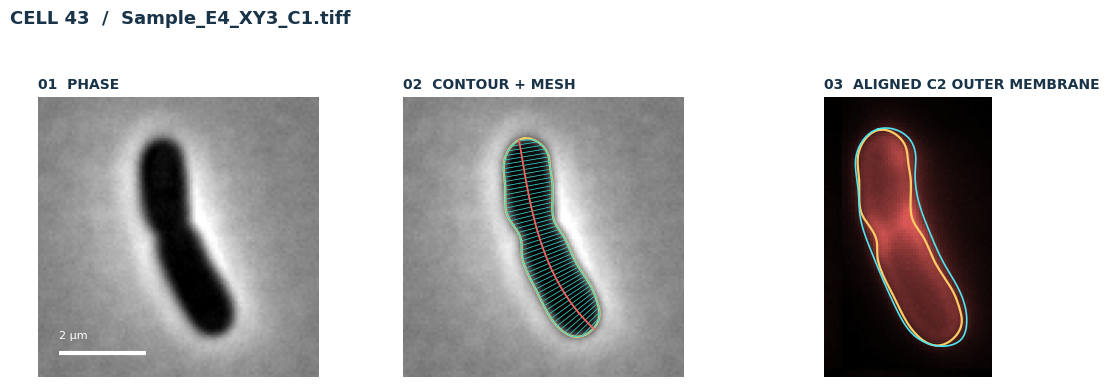

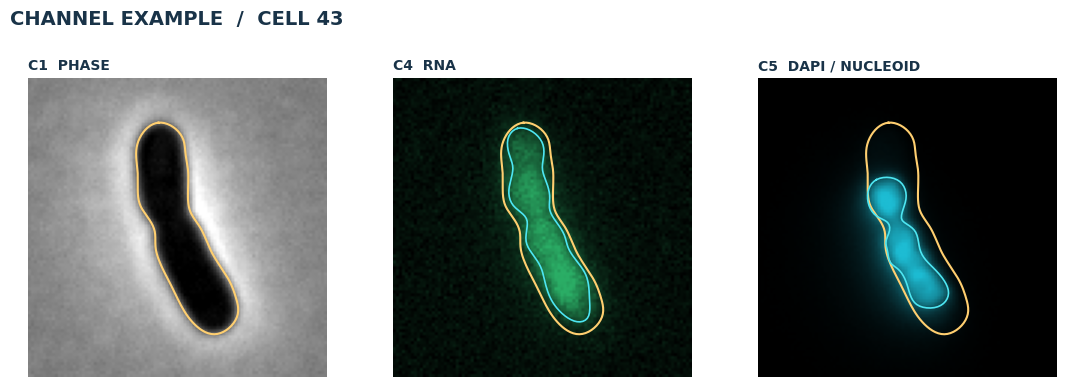

In [85]:
membrane_field = ic.image_objects[0].image_name.rsplit("_", 1)[0]
membrane_image = next(image for image in ic.image_objects
                      if image.image_name.rsplit("_", 1)[0] == membrane_field)
membrane_cell_id = 43
selected_membrane_cell = next(
    (cell for cell in membrane_image.cells if cell.cell_id == membrane_cell_id), None
)
if selected_membrane_cell is None or not selected_membrane_cell.object_meshdata.get(
    OUTER_MEMBRANE, {}
).get("object_contour"):
    print("Selected C2 cell has no detected object; choosing one with a detection.")
    membrane_cell_id = bplt.pick_detected_cell(
        membrane_image, preferred_channels=(OUTER_MEMBRANE,)
    )
print("Aligned C2 example:", membrane_image.image_name, membrane_cell_id)
fig = bplt.plot_cell_gallery(
    membrane_image, membrane_cell_id, channel=OUTER_MEMBRANE,
    channel_label="Outer membrane", align_signal=True, show_objects=True, window_px=100,
)
display(fig)
plt.close(fig)

fig = bplt.plot_signal_gallery(
    ic.image_objects[0], 43,
    channel_labels={RNA_CHANNEL: "RNA", DAPI_CHANNEL: "DAPI / nucleoid"},
    window_px=100, show_objects=True,
)
display(fig)
plt.close(fig)

## 6. Extract features

`channel_method_pairs` groups channels with methods. `morphological` measures cell shape; `membrane` measures contour and membrane intensities; `profiling` produces longitudinal signal profiles; `objects` summarizes detections. C2 uses `shift_signal=True` to measure locally registered signal; C3–C5 use `False`. `reset=False` on the second call preserves C2 features. Tune `max_mesh_size` for your cell sizes. C4/C5 can retain contour measurements if an object mesh fails.

In [86]:
# First pass: outer membrane (signal-shift correction enabled)
ic.batch_calculate_features(
    [
        ([OUTER_MEMBRANE], "membrane"),   # Measure membrane-associated features
        ([OUTER_MEMBRANE], "profiling"),  # Measure intensity profiles across the cell
        ([OUTER_MEMBRANE], "objects"),    # Calculate features of detected objects
    ],
    all_data=False,      # Pass False to the feature methods; its effect is method-specific
    reset=True,          # Clear previously stored feature DataFrames before this pass
    shift_signal=True,   # Enable signal-shift handling for these measurements
    max_mesh_size=1000,  # Exclude cells exceeding the maximum permitted mesh size
)

# Second pass: morphology, inner membrane, RNA and DAPI
ic.batch_calculate_features(
    [
        ([None], "morphological"),  # Cell morphology: length, width, area, volume, etc.
        ([INNER_MEMBRANE], "membrane"),  # Inner-membrane-associated measurements
        ([INNER_MEMBRANE, RNA_CHANNEL, DAPI_CHANNEL], "profiling"),  # Signal intensity profiles
        ([INNER_MEMBRANE, RNA_CHANNEL, DAPI_CHANNEL], "objects"),    # Detected-object features
    ],
    all_data=False,      # Same feature-output setting as the first pass
    reset=False,         # Preserve the outer-membrane feature DataFrames from the first pass
    shift_signal=False,  # Do not apply signal-shift handling in this pass
    max_mesh_size=1000,  # Apply the same maximum mesh-size threshold
    retain_contour_on_object_mesh_failure_channels=[
        RNA_CHANNEL,
        DAPI_CHANNEL,
    ],  # For these channels, retain contour-based object measurements
        # when detected-object mesh construction fails, rather than
        # omitting the affected cell's objects-feature row
)

# Combine the feature DataFrames into one table
analysis_df = ic.merge_dataframes(
    include_metadata_tag=False,       # Do not add the metadata tag to the merged output
    discard_morphological_nan=True,   # Exclude rows failing the merge's morphological NaN checks
)

# Inspect the result
print(f"{len(analysis_df):,} cells × {len(analysis_df.columns)} columns")

display(
    analysis_df[
        ["image_name", "cell_id", "cell_length", "cell_width", "cell_area"]
    ].head()
)


2026-10-01 16:16:33,756 [INFO] PROCESSING CHANNEL: C2, method: membrane


100%|██████████| 2/2 [00:11<00:00,  5.93s/it]

2026-10-01 16:16:45,627 [INFO] PROCESSING CHANNEL: C2, method: profiling



100%|██████████| 2/2 [00:13<00:00,  6.78s/it]

2026-10-01 16:16:59,185 [INFO] PROCESSING CHANNEL: C2, method: objects


...


100%|██████████| 2/2 [00:14<00:00,  7.36s/it]

2026-10-01 16:18:39,336 [INFO] PROCESSING CHANNEL: C5, method: objects



100%|██████████| 2/2 [00:13<00:00,  6.85s/it]

228 cells × 390 columns


,image_name,cell_id,cell_length,cell_width,cell_area
0,Sample_E4_XY3_C1.tiff,5,3.574617,1.175318,3.687470
1,Sample_E4_XY3_C1.tiff,6,3.449281,1.195387,3.607111
2,Sample_E4_XY3_C1.tiff,10,3.752012,1.110344,3.706154
3,Sample_E4_XY3_C1.tiff,14,3.221350,1.147460,3.276404
4,Sample_E4_XY3_C1.tiff,18,3.381874,1.080276,3.233703


## 7. Inspect measurements

We compare cell shape, object occupancy, and dimensionless membrane signal constriction. The figures use within-cell ratios and detected object counts instead of absolute fluorescence intensities, which are difficult to compare across acquisitions. The selected cell's normalized axial profiles remain line plots: C2 red, C3 magenta, C4 green, and C5 blue.

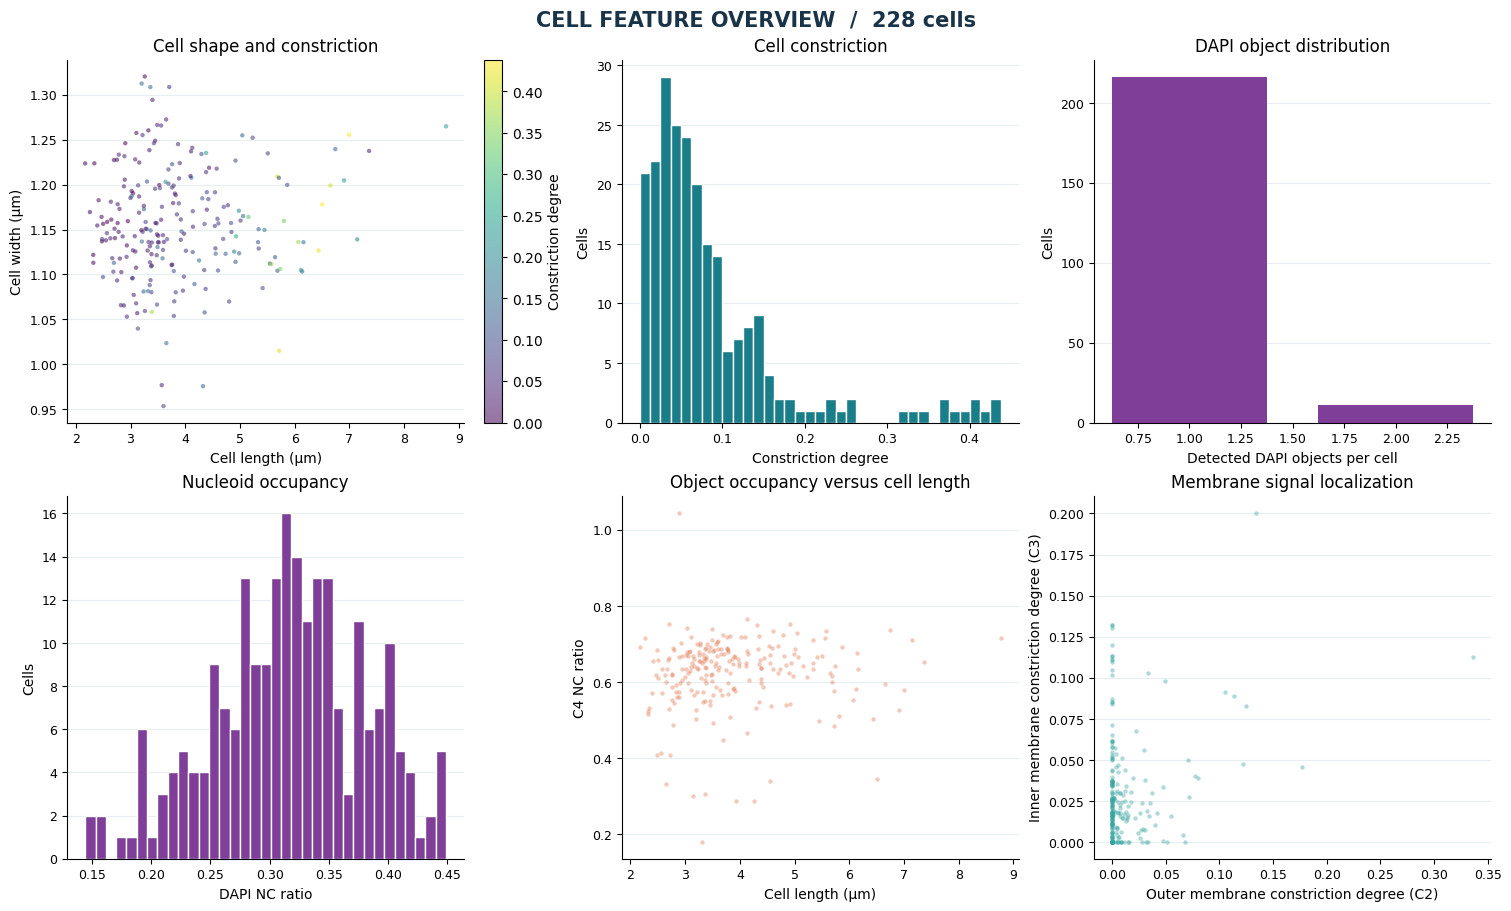

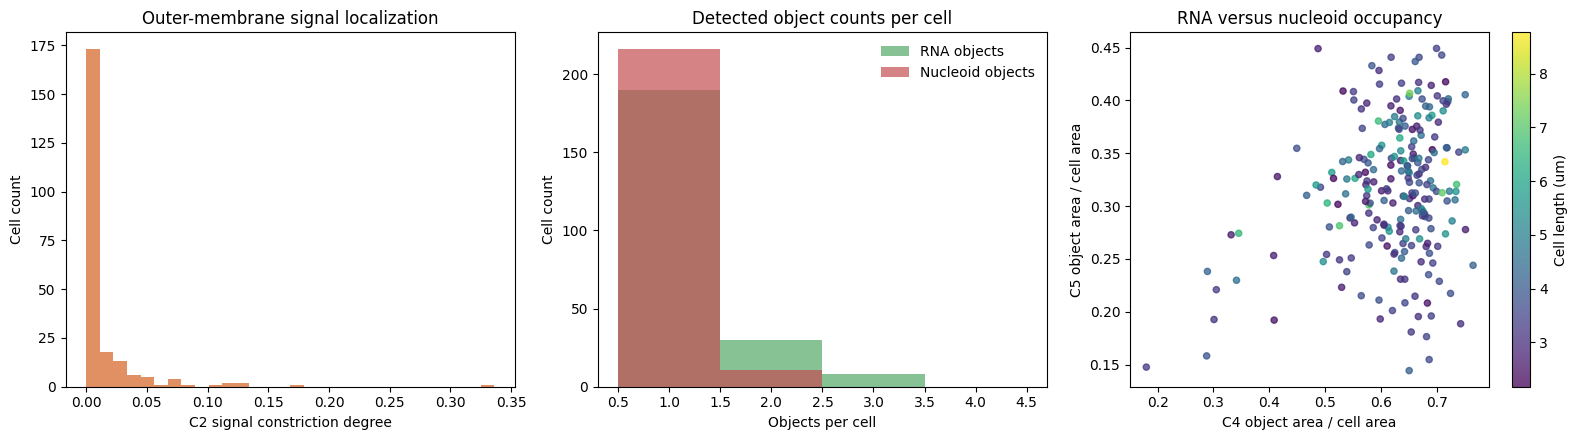

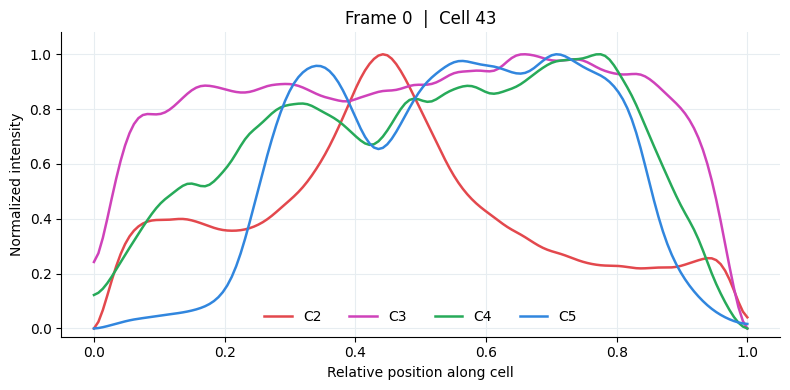

In [87]:
fig = bplt.plot_feature_overview(analysis_df, signal_column="C4_NC_ratio")
display(fig)
plt.close(fig)
bplt.plot_signal_summary(analysis_df)
profile_figures = bplt.plot_normalized_axial_intensity(
    analysis_df, channels=SIGNAL_CHANNELS,
    selected_frame=ic.image_objects[0].frame, selected_cell_id=43,
    show=False,
)
for fig in profile_figures:
    display(fig)
    plt.close(fig)

## 8. Save features and audit

After `merge_dataframes()`, `dataframe_to_parquet()` writes `5_channel_example_features.parquet` and `dataframe_to_pkl()` writes `5_channel_example_features.pkl` in `RUN_DIR`. The pickle method now accepts an exact `.pkl` filename or a suffix tag. Check both image-level and cell-level errors; a row may remain even if a membrane or object measurement failed. These methods need suitable detected contours, so some C2/C3 values can be missing. Inspect the error summary and missing-value counts before downstream analysis.

In [88]:
ic.dataframe_to_parquet()
pickle_path = ic.dataframe_to_pkl()
saved = pd.read_parquet(RUN_DIR / "5_channel_example_features.parquet")
print("Saved Parquet and pickle:", len(saved), "rows;", pickle_path)


Saved Parquet and pickle: 228 rows; C:\Users\Bart\bactoscoop\examples\5_channel_example\5_channel_example_features.pkl
